# AI-Based Career Recommendation System – EDA and Machine Learning Notebook

#### This notebook uses the synthetic dataset [AI-based Career Recommendation System](https://www.kaggle.com/datasets/adilshamim8/ai-based-career-recommendation-system/data) to:
- 1. Load and explore the dataset.
- 2. Perform extensive exploratory data analysis (EDA) to understand the data distribution.
- 3. Preprocess the data to prepare it for machine learning.
- 4. Build and evaluate a simple classification model to predict the recommended career.
- **Note:** The dataset is synthetic. The model and EDA steps serve as an example pipeline.

## Step 1: Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# For preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
# Set style for seaborn
sns.set(style="whitegrid")

In [2]:
# Load the dataset
data = pd.read_csv("/kaggle/input/ai-based-career-recommendation-system/AI-based Career Recommendation System.csv")
data.head()

,CandidateID,Name,Age,Education,Skills,Interests,Recommended_Career,Recommendation_Score
0,1,John Doe,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,Data Scientist,0.95
1,2,Jane Smith,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,Software Engineer,0.90
2,3,Bob Johnson,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,UX Designer,0.88
3,4,Emily Davis,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,AI Researcher,0.93
4,5,Michael Brown,30,Master's,Project Management;Communication;Agile,Business;Management,Project Manager,0.87


# Step 2: Data Overview
> Let's take a look at the basic structure, columns, and summary statistics of the dataset.

In [3]:
print("Dataset Shape:", data.shape)
print("\nDataset Info:")
data.info()

Dataset Shape: (200, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CandidateID           200 non-null    int64  
 1   Name                  200 non-null    object 
 2   Age                   200 non-null    int64  
 3   Education             200 non-null    object 
 4   Skills                200 non-null    object 
 5   Interests             200 non-null    object 
 6   Recommended_Career    200 non-null    object 
 7   Recommendation_Score  200 non-null    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 12.6+ KB


In [4]:
# Display summary statistics for numeric columns
data.describe()

,CandidateID,Age,Recommendation_Score
count,200.000000,200.000000,200.000000
mean,100.500000,30.125000,0.896450
std,57.879185,4.923472,0.028915
min,1.000000,22.000000,0.850000
25%,50.750000,26.750000,0.870000
50%,100.500000,29.000000,0.900000
75%,150.250000,33.000000,0.920000
max,200.000000,41.000000,0.950000


# Step 3: Exploratory Data Analysis (EDA)
## 3.1 Distribution of Age
> We'll look at the distribution of the `Age` column.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


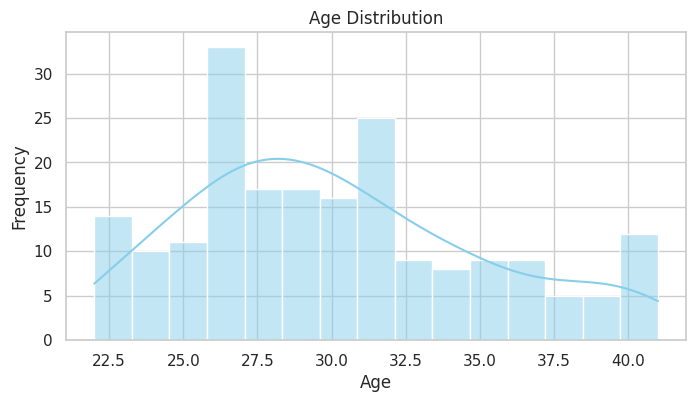

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(data['Age'], bins=15, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 3.2 Count of Education Levels
> Let's examine how many candidates fall into each education category.

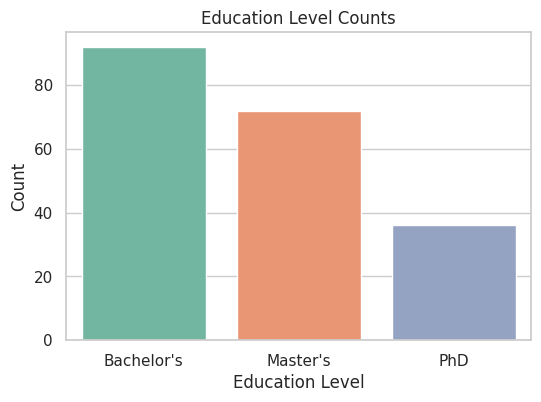

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Education", data=data, palette="Set2")
plt.title("Education Level Counts")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

## 3.3 Recommended Career Distribution
> A count plot for the `Recommended_Career` column to see the frequency of each career recommendation.

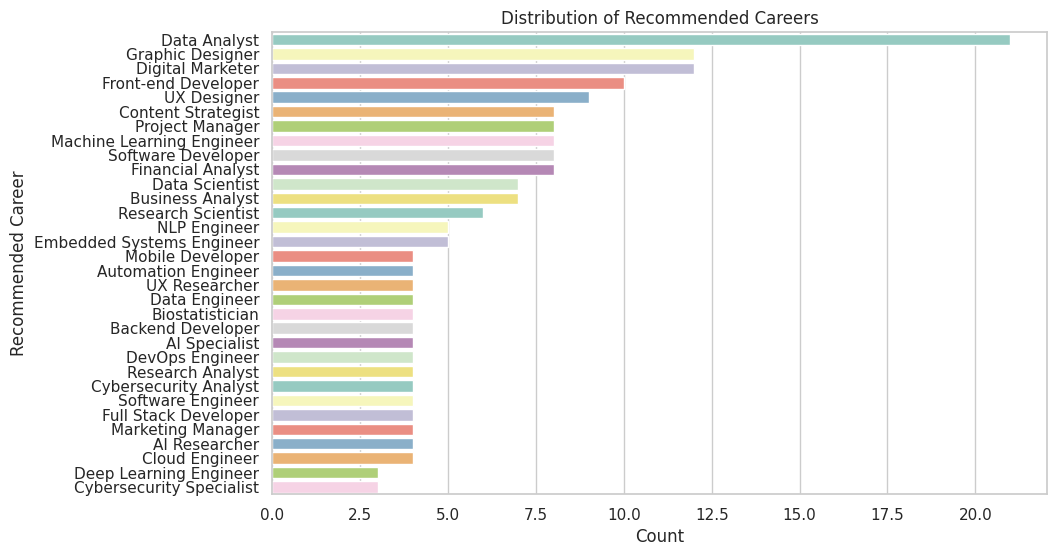

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(y="Recommended_Career", data=data, order=data["Recommended_Career"].value_counts().index, palette="Set3")
plt.title("Distribution of Recommended Careers")
plt.xlabel("Count")
plt.ylabel("Recommended Career")
plt.show()

## 3.4 Recommendation Score Distribution
> Visualize the distribution of the `Recommendation_Score`.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


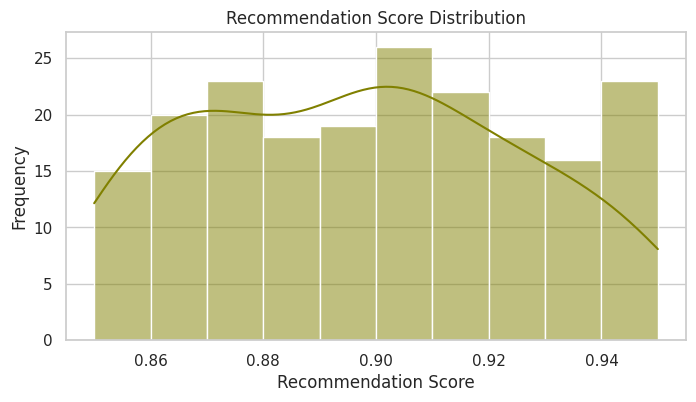

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(data['Recommendation_Score'], bins=10, kde=True, color="olive")
plt.title("Recommendation Score Distribution")
plt.xlabel("Recommendation Score")
plt.ylabel("Frequency")
plt.show()

## 3.5 Skills and Interests Exploration 
> Since `Skills` and `Interests` are stored as semicolon-separated strings, we can explore the most common items. <br>
> We'll split the strings and count the frequency of each skill and interest.

In [9]:
# Function to split semicolon-separated values and count occurrences
def count_items(series):
    items = series.dropna().apply(lambda x: x.split(";"))
    flat_list = [item.strip() for sublist in items for item in sublist]
    return pd.Series(flat_list).value_counts()

In [10]:
# Count Skills
skills_count = count_items(data["Skills"])
print("Most common skills:\n", skills_count)

Most common skills:
 Python              75
Machine Learning    23
SEO                 20
JavaScript          19
Java                18
                    ..
Negotiation          1
Adobe Photoshop      1
UX Design            1
User Research        1
NLP                  1
Name: count, Length: 80, dtype: int64


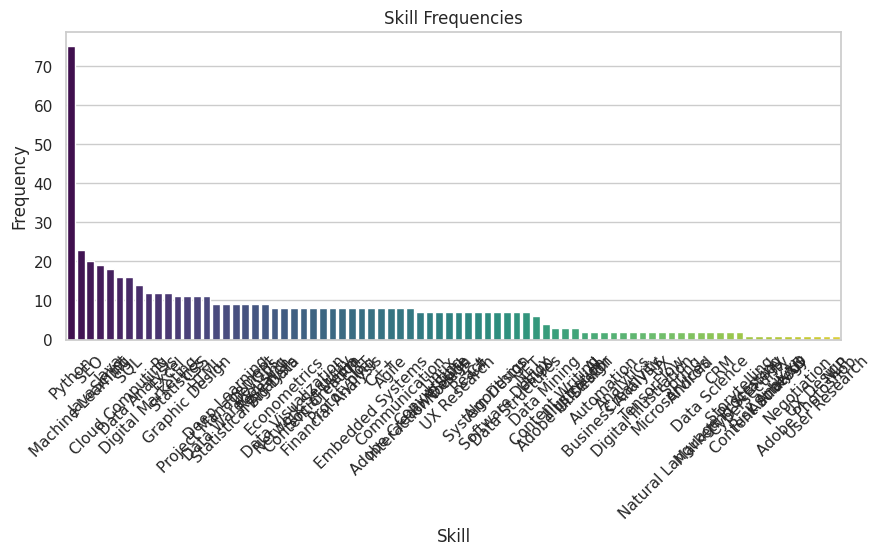

In [11]:
# Plot skills count
plt.figure(figsize=(10, 4))
sns.barplot(x=skills_count.index, y=skills_count.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Skill Frequencies")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.show()

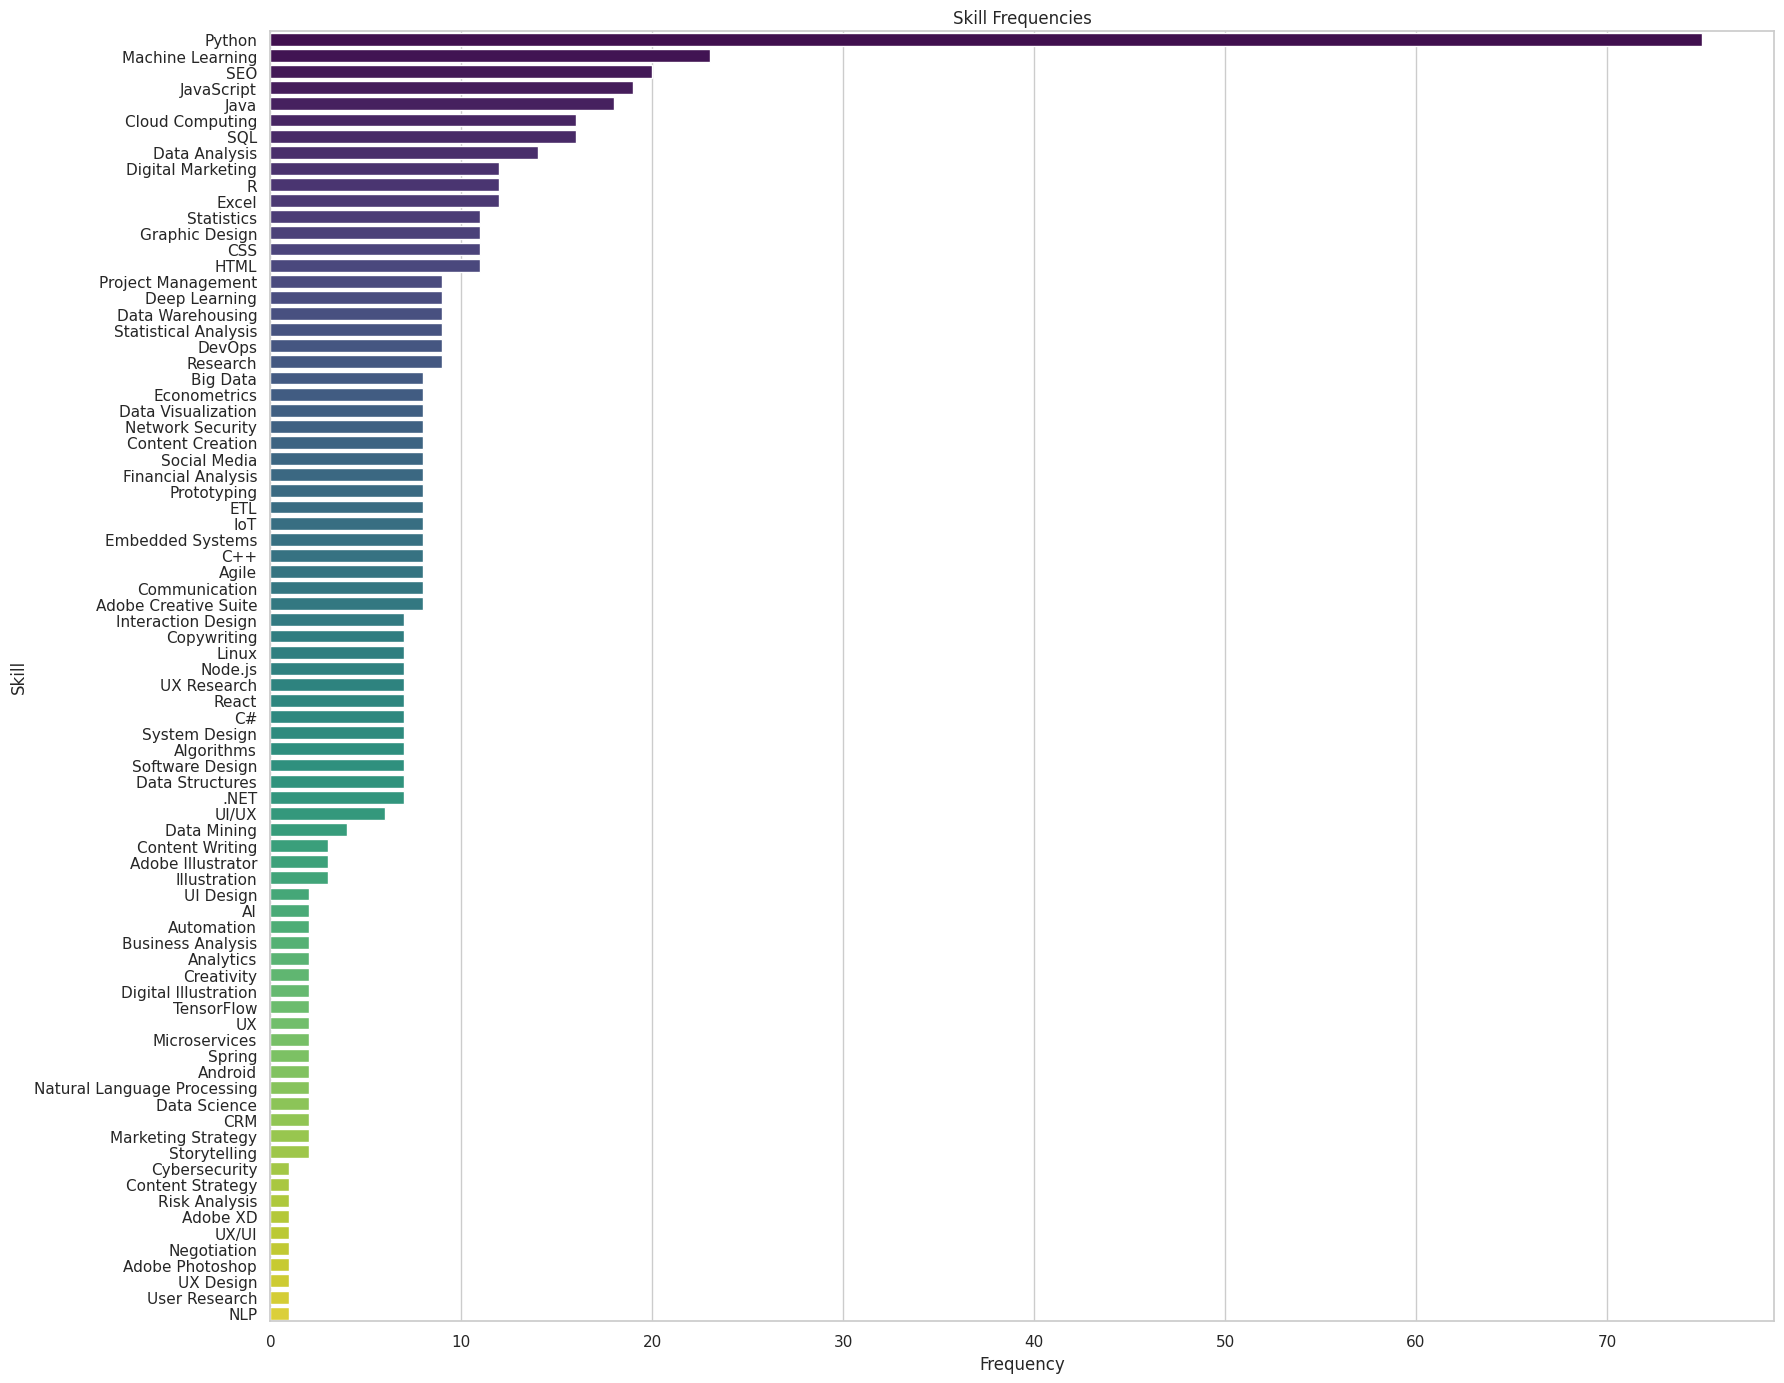

In [12]:
# Plot as horizontal bars with more vertical space
plt.figure(figsize=(18, 14))  # taller figure
sns.barplot(x=skills_count.values, y=skills_count.index, palette="viridis")
plt.title("Skill Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()  # prevents clipping of labels
plt.show()

In [13]:
# Count Interests
interests_count = count_items(data["Interests"])
print("Most common interests:\n", interests_count)

Most common interests:
 Technology              48
AI                      28
Business                28
Finance                 27
Design                  23
Marketing               23
Analytics               19
Data Science            16
Academia                16
Web Development         16
Arts                    16
Management              14
Healthcare              14
Research                13
Digital Media           13
Software Development    13
Communications          12
Cybersecurity           12
Biotech                  6
Data Analysis            5
Innovation               4
Electronics              3
Automation               3
Software Engineering     3
Statistics               2
Coding                   2
Social Media             2
Gaming                   2
Linguistics              2
Web Design               2
Content                  2
Engineering              2
Media                    2
Mobile Apps              2
User Experience          2
Security                 1
Data

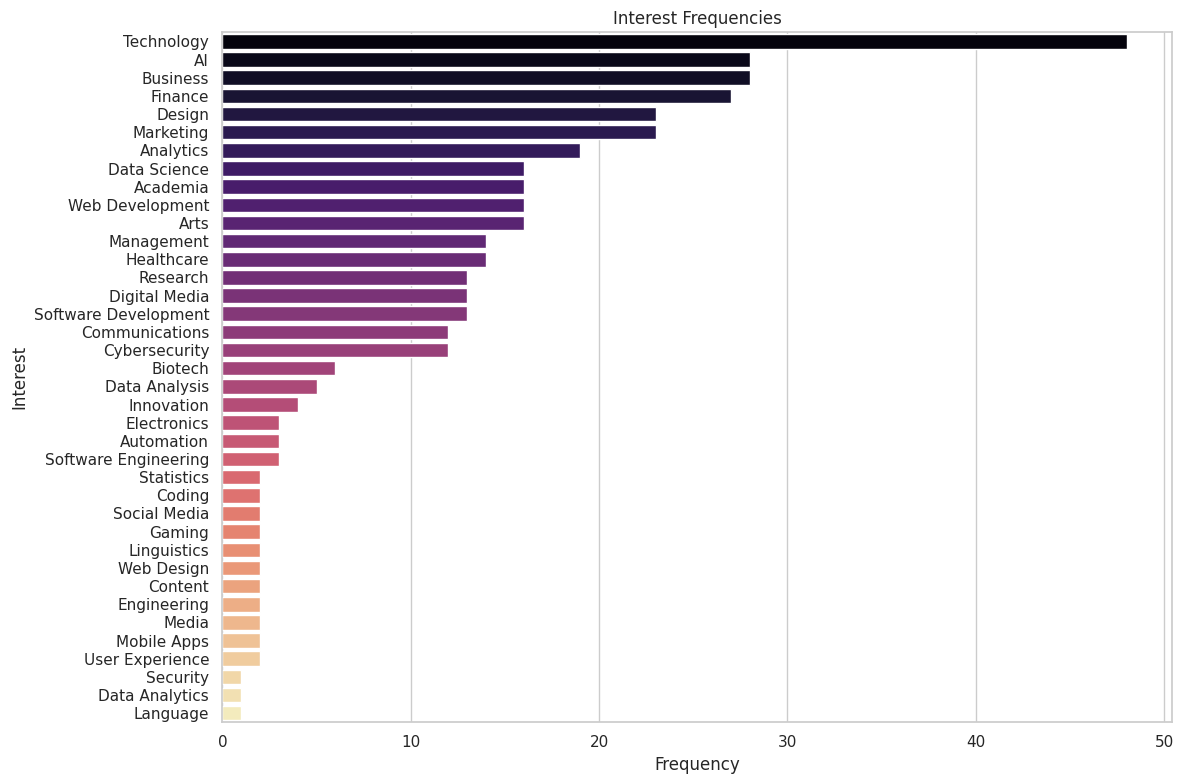

In [14]:
# Plot interests count as horizontal bars
plt.figure(figsize=(12, 8))
sns.barplot(x=interests_count.values, y=interests_count.index, palette="magma")
plt.title("Interest Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Interest")
plt.tight_layout()
plt.show()

# Step 4: Data Preprocessing for Machine Learning
> Our goal is to build a model to predict `Recommended_Career` based on candidate features.
## 4.1 Feature Selection
> We will use:
 - **Age** (numeric)
 - **Education** (categorical, will be label-encoded)
 - **Skills** and **Interests** (text fields, which we will vectorize) <br>
We will drop columns like `CandidateID` and `Name` as they are identifiers and not useful for prediction.

In [15]:
# Select features and target variable
features = data[['Age', 'Education', 'Skills', 'Interests']]
target = data['Recommended_Career']

## 4.2 Encode the Education Column
> Convert the categorical `Education` column into numerical labels.

In [16]:
edu_encoder = LabelEncoder()
features['Education_enc'] = edu_encoder.fit_transform(features['Education'])
features.head()

<ipython-input-16-57252e3da493>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Education_enc'] = edu_encoder.fit_transform(features['Education'])


,Age,Education,Skills,Interests,Education_enc
0,28,Bachelor's,Python;Data Analysis;Machine Learning,Technology;Data Science,0
1,32,Master's,Java;System Design;Cloud Computing,Software Development;AI,1
2,24,Bachelor's,Graphic Design;UI/UX;Adobe Creative Suite,Arts;Digital Media,0
3,26,Bachelor's,Python;Deep Learning;Statistics,Healthcare;AI,0
4,30,Master's,Project Management;Communication;Agile,Business;Management,1


## 4.3 Process Text Fields: Skills and Interests
> We will use `CountVectorizer` to convert the semicolon-separated skills and interests into numerical features. <br>
> First, we join the two text fields into one combined text feature.

In [17]:
# Create a combined text column
features['Text_Features'] = features['Skills'].fillna('') + " " + features['Interests'].fillna('')

# Use CountVectorizer for text feature extraction
vectorizer = CountVectorizer(tokenizer=lambda x: [item.strip() for item in x.split(";") if item.strip()], 
                             lowercase=True)
text_features = vectorizer.fit_transform(features['Text_Features'])

print("Shape of text features:", text_features.shape)

Shape of text features: (200, 150)


<ipython-input-17-3432a9364f73>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Text_Features'] = features['Skills'].fillna('') + " " + features['Interests'].fillna('')
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


## 4.4 Construct the Final Feature Matrix
> We will combine the numeric feature `Age` and the encoded `Education_enc` with the vectorized text features. <br>
> We use scipy's sparse matrix concatenation.

In [18]:
from scipy.sparse import hstack

# Create a numeric matrix from Age and Education_enc
numeric_features = features[['Age', 'Education_enc']].values

In [19]:
# hstack to combine the numeric features with the text features
from scipy import sparse
X = hstack([sparse.csr_matrix(numeric_features), text_features])

In [20]:
# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(target)

print("Feature matrix shape:", X.shape)
print("Target classes:", target_encoder.classes_)

Feature matrix shape: (200, 152)
Target classes: ['AI Researcher' 'AI Specialist' 'Automation Engineer' 'Backend Developer'
 'Biostatistician' 'Business Analyst' 'Cloud Engineer'
 'Content Strategist' 'Cybersecurity Analyst' 'Cybersecurity Specialist'
 'Data Analyst' 'Data Engineer' 'Data Scientist' 'Deep Learning Engineer'
 'DevOps Engineer' 'Digital Marketer' 'Embedded Systems Engineer'
 'Financial Analyst' 'Front-end Developer' 'Full Stack Developer'
 'Graphic Designer' 'Machine Learning Engineer' 'Marketing Manager'
 'Mobile Developer' 'NLP Engineer' 'Project Manager' 'Research Analyst'
 'Research Scientist' 'Software Developer' 'Software Engineer'
 'UX Designer' 'UX Researcher']


# Step 5: Build and Evaluate a Machine Learning Model
>  We'll use a Random Forest Classifier for this example.
## 5.1 Split the Data into Training and Testing Sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (160, 152)
Testing set shape: (40, 152)


## 5.2 Train the Random Forest Classifier

In [22]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 5.3 Model Evaluation
> We'll evaluate the model using a confusion matrix and classification report.

In [23]:
# Predict on the test set
y_pred = clf.predict(X_test)

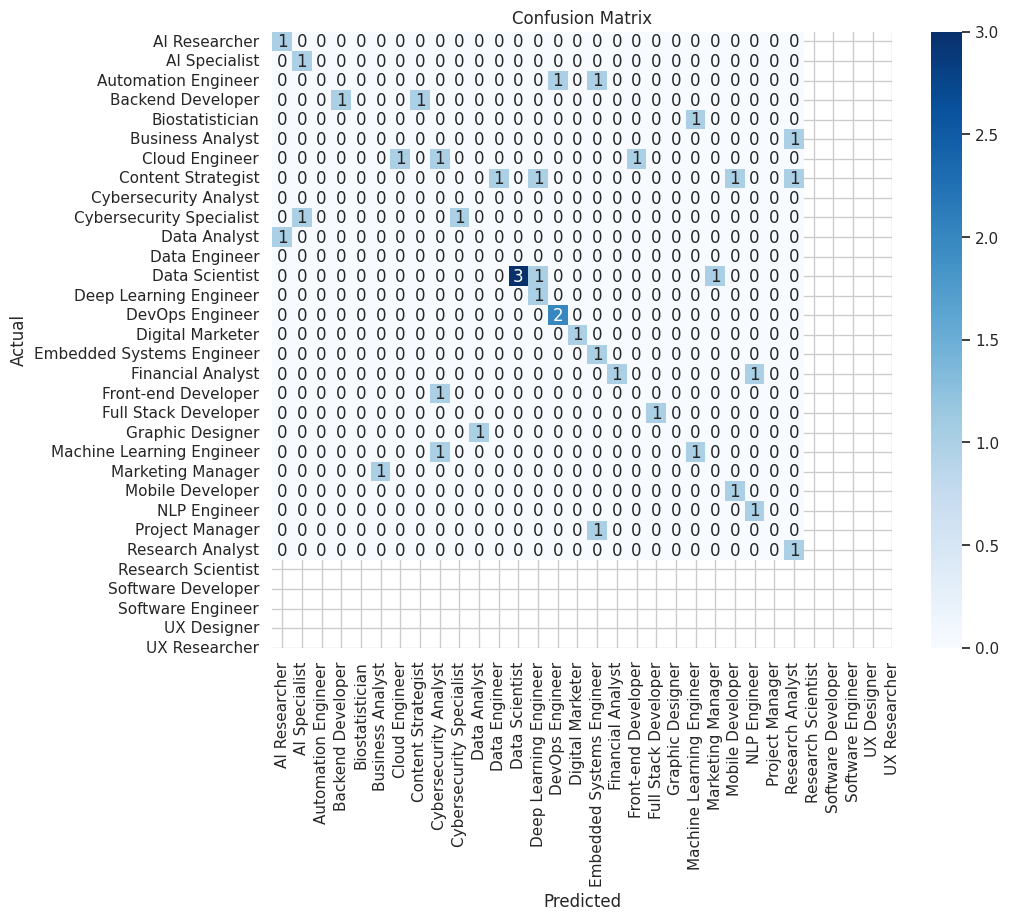

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 6: Summary and Next Steps
### In this notebook, we:
 - Loaded the synthetic career dataset.
 - Explored the data through various EDA techniques.
 - Preprocessed numeric and text features.
 - Built a simple Random Forest model to predict the recommended career.
### **Next Steps:**
 - Experiment with other feature engineering techniques (e.g., TF-IDF for text).
 - Try different machine learning algorithms.
 - Tune hyperparameters to improve model performance.
 - Explore the relationship between candidate attributes and career recommendations further. <br>
This pipeline can serve as a foundation for developing a more robust career recommendation system.

### Connect with Me  

Feel free to follow me on these platforms:  

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=for-the-badge&logo=github&logoColor=white)](https://github.com/AdilShamim8)  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/adilshamim8)  
[![Twitter](https://img.shields.io/badge/Twitter-1DA1F2?style=for-the-badge&logo=twitter&logoColor=white)](https://x.com/adil_shamim8)  